# 05 · Round 2 — revalidation after redevelopment

Round 1 (notebooks 01-04) rejected `gbm` (single Monte-Carlo path, F1) and `clam_orig` (train/inference
mismatch F3, in-sample contamination F4). The model owner redeveloped both for a **weekly** horizon:

| new candidate | what changed | developer-side selection |
|---|---|---|
| `gbm_weekly` | horizon 5d, closed-form score instead of one simulated path | best of 6 variants (lookback 63/126/252 × expected/prob_up) on the development sample < 2022 → `gbm_w_126_expected` |
| `clam_weekly_cs_demeaned` | per-ticker sequences (F3), training cut 2021-12-31 (F4), 5-day scalar target minus that week's cross-sectional mean, top-500 universe | validation rank IC 0.014 |
| `clam_weekly_cs_rank_small` | as above with a within-week percentile-rank target and a smaller network | validation rank IC 0.016 |

Every variant tried (6 GBM + 3 CLAM incl. one discarded) is counted: `config.N_TRIALS_DSR = 11` (plus the `clam_2021` twin: the original CLAM code retrained with a 2021-12-31 cut-off). This
notebook re-runs the three questions on the new candidates alongside the round-1 models. Nothing about the
new models was chosen by looking at data after `config.OOT_START`.

In [1]:
import sys; sys.path.insert(0, "..")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import config
from sv import db

con = db.connect(read_only=True)
q   = lambda name, **p: db.run_sql_file(con, name, p or None)   # run sql/queries/<name>.sql
sql = lambda text, **p: db.read(con, text, p or None)           # run an inline query
pd.set_option("display.width", 140); plt.rcParams["figure.figsize"] = (10, 4)

In [2]:
NEW = ["gbm_weekly", "clam_2021", "clam_weekly_cs_demeaned", "clam_weekly_cs_rank_small"]
OLD = ["momentum", "gbm", "gbm_expected"]

## Developer-side selection table (development sample only)

In [3]:
sql("""SELECT strategy, COUNT(*) AS weeks, ROUND(AVG(ret_net) / STDDEV_SAMP(ret_net) * SQRT(52), 3) AS sharpe_dev,
              ROUND(AVG(turnover), 3) AS turnover
       FROM portfolio_returns WHERE strategy LIKE 'gbm_w_%' AND date < $s GROUP BY strategy ORDER BY sharpe_dev DESC""", s=config.OOT_START)

,strategy,weeks,sharpe_dev,turnover
0,gbm_weekly,366,0.903,0.202
1,gbm_w_126_expected,366,0.903,0.202
2,gbm_w_126_prob_up,366,0.823,0.263
3,gbm_w_252_expected,366,0.791,0.148
4,gbm_weekly_lag1,366,0.724,0.202
5,gbm_w_63_prob_up,366,0.618,0.367
6,gbm_w_252_prob_up,366,0.586,0.198
7,gbm_w_63_expected,366,0.584,0.287
8,gbm_weekly_gated,366,0.452,0.190


## Q1 — overfitting tests, all models

In [4]:
vr = sql("""SELECT model, test, ROUND(statistic,3) AS statistic, ROUND(ci_low,3) AS ci_low, ROUND(ci_high,3) AS ci_high,
                   ROUND(p_value,3) AS p_value, verdict, detail FROM validation_results ORDER BY model, test""")
vr.pivot(index="model", columns="test", values="verdict").loc[OLD + NEW]

test,bootstrap_sharpe_ci,deflated_sharpe,permutation_null
model,,,
momentum,PASS,FAIL,PASS
gbm,FAIL,FAIL,FAIL
gbm_expected,FAIL,FAIL,FAIL
gbm_weekly,PASS,FAIL,PASS
clam_2021,FAIL,FAIL,FAIL
clam_weekly_cs_demeaned,FAIL,FAIL,FAIL
clam_weekly_cs_rank_small,FAIL,FAIL,FAIL


In [5]:
vr[vr.model.isin(NEW)]

,model,test,statistic,ci_low,ci_high,p_value,verdict,detail
0,clam_2021,bootstrap_sharpe_ci,-0.045,-0.570,0.435,0.586,FAIL,"stationary block bootstrap, block=13w, n=5000,..."
1,clam_2021,deflated_sharpe,0.002,NaN,NaN,0.998,FAIL,"N_trials=11, SR0(ann)=0.81, skew=0.02, kurt=5...."
2,clam_2021,permutation_null,0.161,-0.577,0.607,0.298,FAIL,cross-sectional permutation on gross active re...
3,clam_weekly_cs_demeaned,bootstrap_sharpe_ci,-0.676,-1.219,-0.123,0.993,FAIL,"stationary block bootstrap, block=13w, n=5000,..."
4,clam_weekly_cs_demeaned,deflated_sharpe,0.000,NaN,NaN,1.000,FAIL,"N_trials=11, SR0(ann)=0.81, skew=0.18, kurt=4...."
5,clam_weekly_cs_demeaned,permutation_null,-0.129,-0.524,0.665,0.710,FAIL,cross-sectional permutation on gross active re...
6,clam_weekly_cs_rank_small,bootstrap_sharpe_ci,0.038,-0.476,0.530,0.431,FAIL,"stationary block bootstrap, block=13w, n=5000,..."
7,clam_weekly_cs_rank_small,deflated_sharpe,0.004,NaN,NaN,0.996,FAIL,"N_trials=11, SR0(ann)=0.81, skew=0.18, kurt=5...."
8,clam_weekly_cs_rank_small,permutation_null,0.389,-0.523,0.620,0.102,FAIL,cross-sectional permutation on gross active re...
15,gbm_weekly,bootstrap_sharpe_ci,0.493,0.019,0.940,0.020,PASS,"stationary block bootstrap, block=13w, n=5000,..."


## Out-of-time performance (2022 →), champion vs gated challenger

In [6]:
cc = q("champion_challenger", start=config.OOT_START).set_index("strategy").round(3)
cc.loc[[s for s in cc.index if any(s.startswith(m) for m in OLD + NEW) or s in ("universe_ew", "benchmark_spy")]]

,weeks,cagr,vol,sharpe,max_drawdown,total_return
strategy,,,,,,
benchmark_spy,245,0.124,0.165,0.793,-0.223,0.735
clam_2021,246,0.166,0.309,0.652,-0.331,1.065
clam_2021_gated,246,-0.003,0.018,-0.154,-0.033,-0.014
clam_2021_lag1,246,0.097,0.287,0.467,-0.284,0.550
clam_weekly_cs_demeaned,246,-0.001,0.268,0.130,-0.390,-0.004
clam_weekly_cs_demeaned_gated,246,0.000,0.000,NaN,0.000,0.000
clam_weekly_cs_demeaned_lag1,246,-0.024,0.260,0.035,-0.319,-0.109
clam_weekly_cs_rank_small,246,0.107,0.225,0.565,-0.241,0.617
clam_weekly_cs_rank_small_gated,246,0.000,0.000,NaN,0.000,0.000


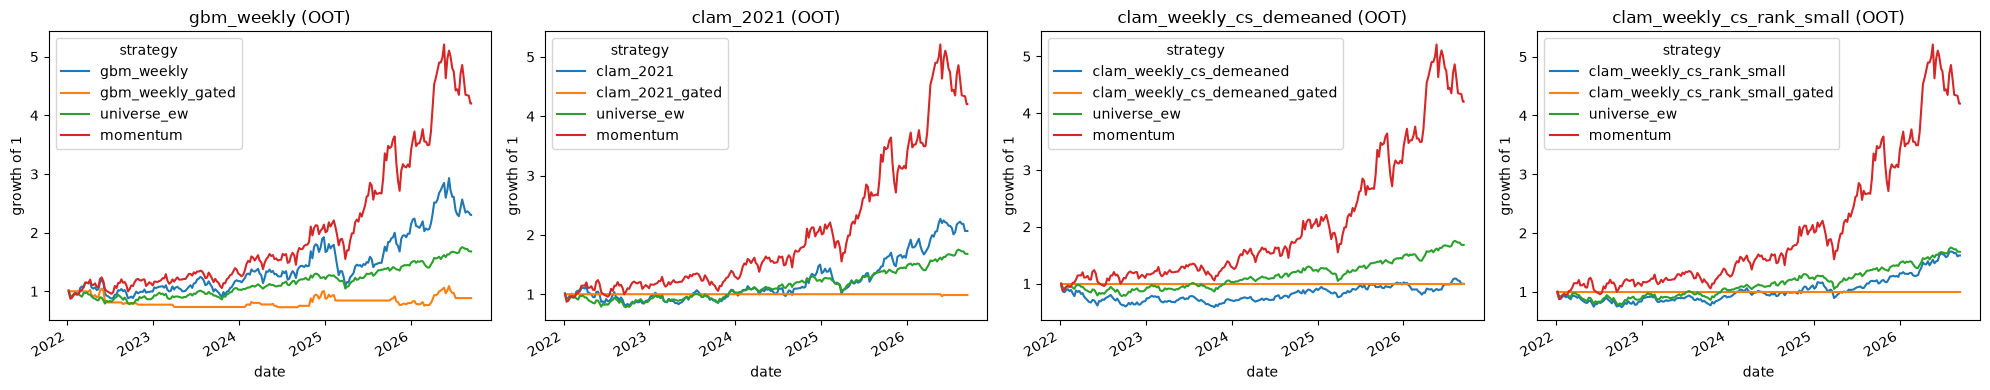

In [7]:
pr = sql("SELECT date, strategy, ret_net FROM portfolio_returns WHERE date >= $s", s=config.OOT_START)
eq = (1 + pr.pivot(index="date", columns="strategy", values="ret_net").fillna(0)).cumprod()
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, m in zip(axes, NEW):
    eq[[m, f"{m}_gated", "universe_ew", "momentum"]].plot(ax=ax, title=f"{m} (OOT)"); ax.set_ylabel("growth of 1")
plt.tight_layout(); plt.show()

## Q2 — monitoring: did the redevelopment fix the CLAM distribution shift?

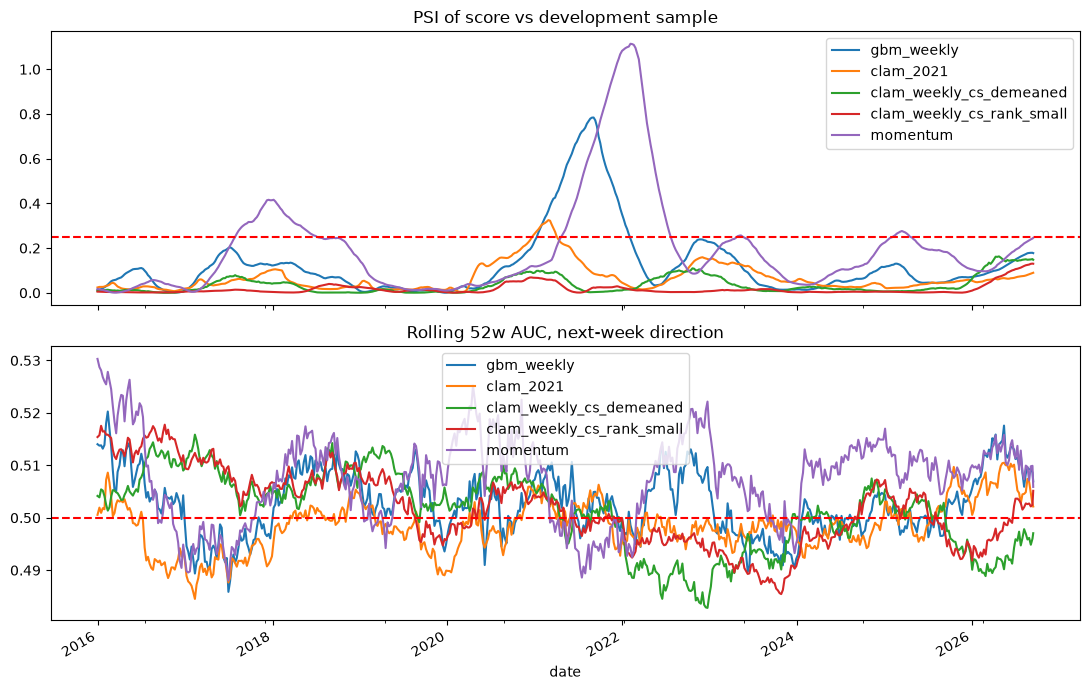

In [8]:
mon = sql("SELECT date, model, metric, value FROM monitoring WHERE model = ANY($m)", m=OLD + NEW)
wide = {m: g.pivot(index="date", columns="metric", values="value") for m, g in mon.groupby("model")}
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
for m in NEW + ["momentum"]:
    wide[m]["psi_score"].plot(ax=axes[0], label=m); wide[m]["auc_1w"].plot(ax=axes[1], label=m)
axes[0].axhline(.25, color="r", ls="--"); axes[0].set_title("PSI of score vs development sample"); axes[0].legend()
axes[1].axhline(.5, color="r", ls="--"); axes[1].set_title("Rolling 52w AUC, next-week direction"); axes[1].legend()
plt.tight_layout(); plt.show()

In [9]:
pd.concat({m: q("auc_by_year", model=m).set_index("year")["auc"] for m in NEW + ["momentum"]}, axis=1).round(3)

,gbm_weekly,clam_2021,clam_weekly_cs_demeaned,clam_weekly_cs_rank_small,momentum
year,,,,,
2015,0.516,0.502,0.503,0.516,0.531
2016,0.495,0.489,0.511,0.509,0.490
2017,0.502,0.496,0.505,0.507,0.507
2018,0.507,0.504,0.509,0.508,0.504
2019,0.497,0.490,0.503,0.497,0.509
2020,0.508,0.505,0.505,0.504,0.513
2021,0.497,0.495,0.497,0.498,0.496
2022,0.505,0.498,0.487,0.494,0.515
2023,0.493,0.495,0.500,0.492,0.496


## Q3 — gate statistics

In [10]:
sql("""SELECT model, COUNT(*) AS weeks, ROUND(AVG((NOT gate_on)::INT), 3) AS share_off FROM gate_decisions
       WHERE model = ANY($m) GROUP BY model ORDER BY model""", m=OLD + NEW)

,model,weeks,share_off
0,clam_2021,612,0.920
1,clam_weekly_cs_demeaned,612,0.915
2,clam_weekly_cs_rank_small,612,0.614
3,gbm,612,0.915
4,gbm_expected,612,0.627
5,gbm_weekly,612,0.588
6,momentum,612,0.475


## Execution-lag sensitivity (finding F5) on the new candidates

In [11]:
rows = []
for m in NEW + ["momentum"]:
    a, b = cc.loc[m], cc.loc[f"{m}_lag1"]
    rows.append({"model": m, "cagr_close": a.cagr, "cagr_next_day": b.cagr, "share_lost": 1 - b.cagr / a.cagr if a.cagr else np.nan})
pd.DataFrame(rows).set_index("model").round(3)

,cagr_close,cagr_next_day,share_lost
model,,,
gbm_weekly,0.193,0.083,0.570
clam_2021,0.166,0.097,0.416
clam_weekly_cs_demeaned,-0.001,-0.024,-23.000
clam_weekly_cs_rank_small,0.107,0.091,0.150
momentum,0.355,0.192,0.459


## Decision inputs

A redeveloped model is approvable only if it (1) passes at least the bootstrap and permutation tests,
(2) beats the untuned momentum benchmark out-of-time on active Sharpe, and (3) shows AUC > 0.5 in the
majority of out-of-time years. The verdicts above feed §12 of the report.